# Import libraries

In [16]:
import os
os.environ["OMP_NUM_THREADS"] = "1" # This eliminates the potential memory leak during K-means

In [17]:
import numpy as np
import pandas as pd

# Load In-built Iris Dataset

In [18]:
from sklearn.datasets import load_iris

iris = load_iris()

X = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

In [19]:
print("Dataset Shape:", X.shape)

X.head()

Dataset Shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


# Data Preprocessing

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Data Standardized Successfully")

Data Standardized Successfully


# K-Means Clustering

In [21]:
from sklearn.cluster import KMeans

In [22]:
kmeans = KMeans(
    n_clusters = 3,
    random_state = 42
)

kmeans_labels = kmeans.fit_predict(X_scaled)
print("K-Means Clustering Completed")

K-Means Clustering Completed


# Visualization

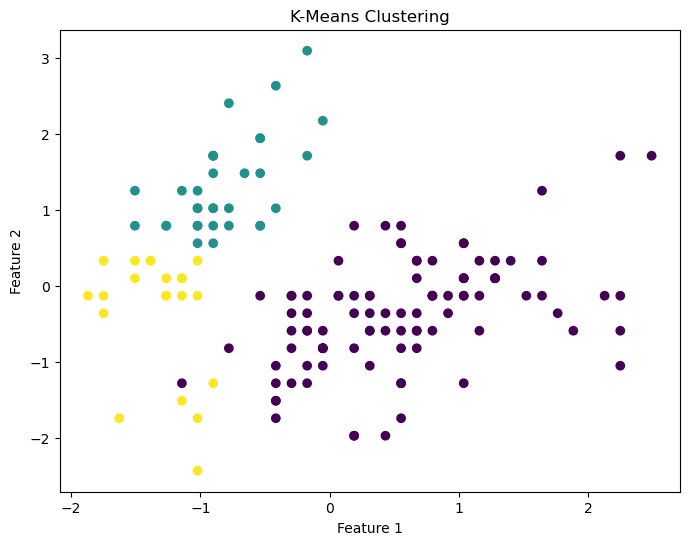

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=kmeans_labels
)

plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

# Hierarchical Clustering

In [24]:
from sklearn.cluster import AgglomerativeClustering

In [25]:
hierarchical = AgglomerativeClustering(
    n_clusters = 3
)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

print("Hierarchical Clustering Completed")

Hierarchical Clustering Completed


# Visualization

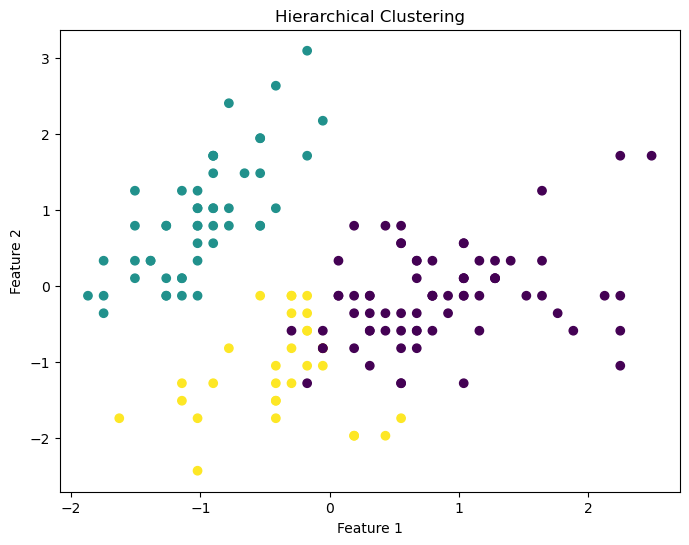

In [26]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=hierarchical_labels
)

plt.title("Hierarchical Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

# DBSCAN Clustering

In [27]:
from sklearn.cluster import DBSCAN

In [28]:
dbscan = DBSCAN(
    eps=0.8,
    min_samples = 5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

print("DBSCAN Clustering Completed")

DBSCAN Clustering Completed


# Visualization

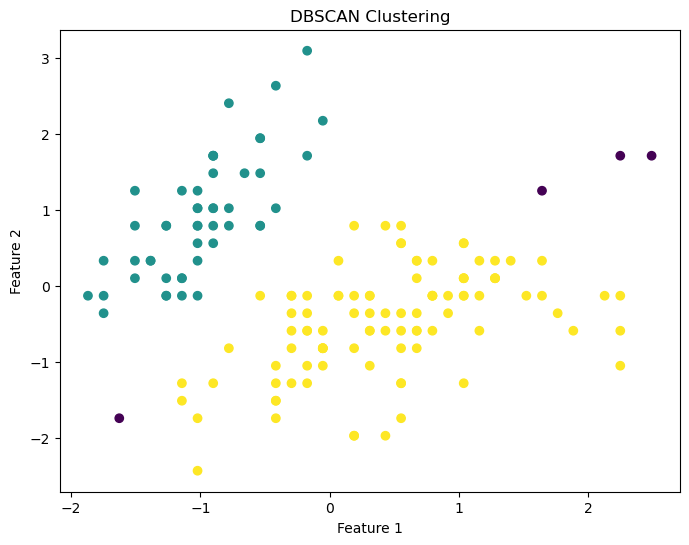

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=dbscan_labels
)

plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

# MODEL COMPARISON

In [30]:
from sklearn.metrics import silhouette_score

In [31]:
kmeans_score = silhouette_score(
    X_scaled,
    kmeans_labels
)

hierarchical_score = silhouette_score(
    X_scaled,
    hierarchical_labels
)

dbscan_score = silhouette_score(
    X_scaled,
    dbscan_labels
)

comparison = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Hierarchical",
        "DBSCAN"
    ],
    "Silhouette Score": [
        kmeans_score,
        hierarchical_score,
        dbscan_score
    ]
})

comparison

,Algorithm,Silhouette Score
0,K-Means,0.479881
1,Hierarchical,0.446689
2,DBSCAN,0.521697
